
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Clasificación con una Red Neuronal Profunda con TensorFlow y Pytorch</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Construir, entrenar y evaluar un MLP profundo en TensorFlow y Pytorch sobre un conjunto de datos real, aplicando las técnicas vistas (regularización, optimizadores, curvas de aprendizaje).
</div>


### Instrucciones

Trabajaremos con el dataset de imágenes **CIFAR-10**: 60 000 imágenes a color de $32\times32$ píxeles (50 000 de entrenamiento y 10 000 de prueba) repartidas en **10 clases** (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión). Está disponible de forma nativa tanto en TensorFlow (`keras.datasets.cifar10`) como en PyTorch (`torchvision.datasets.CIFAR10`).

1. **Carga y explora** el dataset: normaliza los píxeles a $[0, 1]$, **aplana** cada imagen a un vector de $32\times32\times3 = 3072$ valores (para el MLP) y **visualiza** algunos ejemplos con su clase.
2. Divide en train/validación y usa el conjunto de prueba oficial.
3. Construye un **MLP profundo con Tensorflow** (**Modelo 1**): al menos 3 capas ocultas, con `BatchNormalization`, `Dropout` y optimizador **Adam**. Define la entrada con `keras.Input(shape=(3072,))`. Entrena y reporta la precisión en test.
4. Construye el **mismo MLP con PyTorch** (**Modelo 2**): entrena con **AdamW** y un **scheduler** de tu elección (p. ej. `StepLR` o `CosineAnnealingLR`).
5. Grafica las **curvas de aprendizaje** (pérdida y precisión) de ambos modelos y reporta la **precisión en test**.
6. Muestra la **matriz de confusión** e identifica qué clases se confunden más.
7. **Compara** ambas implementaciones y anota tus conclusiones.

> un MLP sobre imágenes a color suele alcanzar ~45–55 % de precisión en CIFAR-10. Es un buen punto de partida para motivar el uso de **redes convolucionales (CNN)** más adelante.


### 1. Carga y exploración del dataset (CIFAR-10)

Esta parte ya está resuelta: carga el dataset, lo normaliza, lo aplana y muestra algunos ejemplos. Reutilizarás estas variables (`X_train`, `y_train`, `X_test`, `y_test`) en ambos modelos.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 38s 0us/step
Entrenamiento: (50000, 3072) | Prueba: (10000, 3072)
Clases: [0 1 2 3 4 5 6 7 8 9]


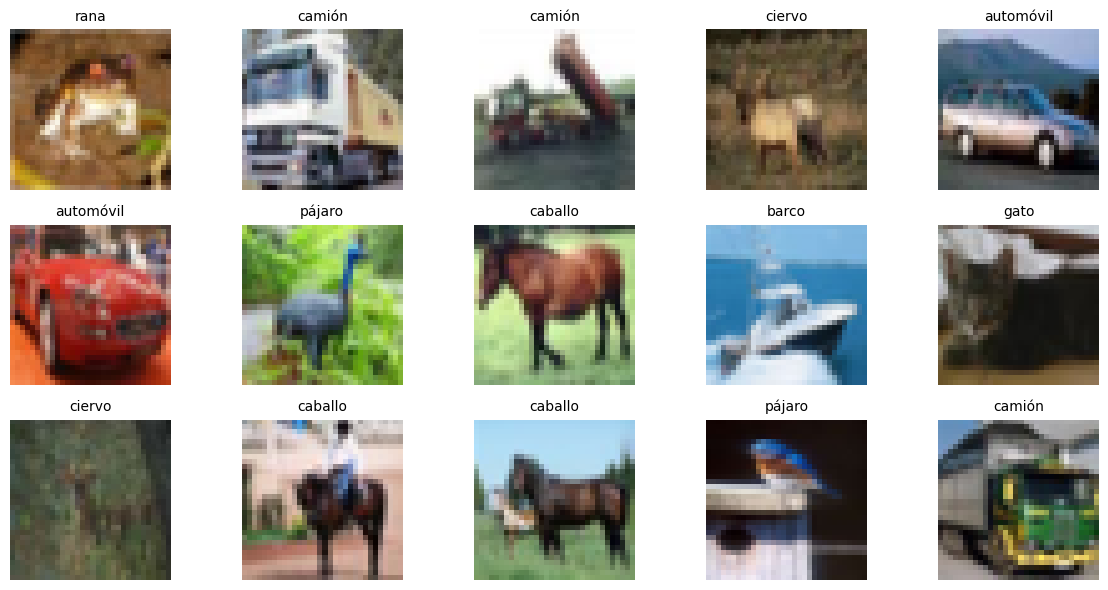

In [1]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Nombres de las 10 clases de CIFAR-10
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Cargar el dataset (imágenes 32x32x3, etiquetas 0-9)
(X_train_img, y_train), (X_test_img, y_test) = cifar10.load_data()
y_train, y_test = y_train.ravel(), y_test.ravel()   # de (N,1) a (N,)

# Normalizar a [0,1] y aplanar a vectores de 3072 (para el MLP)
X_train = (X_train_img / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')
X_test  = (X_test_img  / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)
print('Clases:', np.unique(y_train))

# Visualizar 15 imágenes con su clase
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train_img[i])          # imagen original a color
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

### 2. Divide en train/validación y usa el conjunto de prueba oficial.

En este apartado dividimos los datos para train y test los cuales se utilizarán en ambos modelos.

In [6]:
# Tenemos ya los datos de entrenamiento y prueba listos para entrenar un MLP con TensorFlow y PyTorch.
X_train.shape

(50000, 3072)

### 3. Modelo con TensorFlow
Se crea un **MLP profundo con Tensorflow**: al menos 3 capas ocultas, con `BatchNormalization`, `Dropout` y optimizador **Adam**. Define la entrada con `keras.Input(shape=(3072,))`. Se entrena y reporta la precisión en test

In [8]:
import tensorflow as tf

NB_CLASSES = 10
N_HIDDEN = 512
DROPOUT = 0.3            # fracción de neuronas desactivadas en cada capa de dropout
EPOCHS = 60
BATCH_SIZE = 128

# 1: construye un MLP profundo con la API Sequential
model_tf = tf.keras.models.Sequential()

# Capa de entrada - keras.Input(shape=(3072,))
model_tf.add(tf.keras.Input(shape=(3072,), name = 'input_layer'))

# Primera capa oculta (ReLU) - >= 3 capas Dense ocultas (p. ej. 512, 256, 128) con activación 'relu'
model_tf.add(tf.keras.layers.Dense(N_HIDDEN, activation='relu', name = 'dense_layer_1'))
model_tf.add(tf.keras.layers.BatchNormalization(name = 'batch_norm_layer_1'))
model_tf.add(tf.keras.layers.Dropout(DROPOUT, name = 'dropout_layer_1'))

# Segunda capa oculta (ReLU) 
model_tf.add(tf.keras.layers.Dense(N_HIDDEN // 2, activation='relu', name = 'dense_layer_2'))
model_tf.add(tf.keras.layers.BatchNormalization(name = 'batch_norm_layer_2'))
model_tf.add(tf.keras.layers.Dropout(DROPOUT, name = 'dropout_layer_2'))

# Tercera capa oculta (ReLU) - usa BatchNormalization y Dropout entre capas
model_tf.add(tf.keras.layers.Dense(N_HIDDEN // 4, activation='relu', name = 'dense_layer_3'))
model_tf.add(tf.keras.layers.BatchNormalization(name = 'batch_norm_layer_3'))
model_tf.add(tf.keras.layers.Dropout(DROPOUT, name = 'dropout_layer_3'))

# Capa de salida (softmax) - Dense(10, activation='softmax')
model_tf.add(tf.keras.layers.Dense(NB_CLASSES, activation='softmax', name = 'dense_layer_4'))

# 2: compila con optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']
model_tf.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# 3: entrena guardando el history (usa validation_split=0.1 y varias épocas)
history_tf = model_tf.fit(X_train, y_train, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH_SIZE)

# 4: evalúa en test e imprime la precisión
test_loss, test_acc = model_tf.evaluate(X_test, y_test)
test_loss, test_acc

Epoch 1/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3040 - loss: 2.0298 - val_accuracy: 0.3636 - val_loss: 1.8209
Epoch 2/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3808 - loss: 1.7333 - val_accuracy: 0.3948 - val_loss: 1.6917
Epoch 3/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.4094 - loss: 1.6544 - val_accuracy: 0.3268 - val_loss: 1.8458
Epoch 4/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.4204 - loss: 1.6229 - val_accuracy: 0.3474 - val_loss: 1.8222
Epoch 5/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.4238 - loss: 1.6148 - val_accuracy: 0.4164 - val_loss: 1.6293
Epoch 6/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.4309 - loss: 1.5990 - val_accuracy: 0.4338 - val_loss: 1.5859
Epoch 7/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.4348 - loss: 1.5768 - val_accuracy: 0.4520 - val_loss: 1.5530
Epoch 8/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.4438 - loss: 1.5575 - 

(1.425885796546936, 0.49480000138282776)

### 4. Modelo con Pytorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reutilizamos los MISMOS datos de CIFAR-10 ya normalizados y aplanados (3072)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Separa un 10% del entrenamiento para validación
n_val = int(0.1 * len(X_train_t))
train_ds = TensorDataset(X_train_t[:-n_val], y_train_t[:-n_val])
val_ds   = TensorDataset(X_train_t[-n_val:], y_train_t[-n_val:])
test_ds  = TensorDataset(X_test_t, y_test_t)

# Crea TensorDataset y DataLoader (train/val/test) con batch_size=128
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

#print('Tensores listos:', X_train_t.shape, X_test_t.shape, '| Dispositivo:', device)
print("Dispositivo:", device)
print("Entrenamiento:", len(train_ds), "| Validación:", len(val_ds), "| Prueba:", len(test_ds))

In [ ]:
# TODO 3: define tu MLP profundo (>= 3 capas ocultas, BatchNorm, Dropout)
#   Entrada: 3072 features -> salida: 10 clases (logits, sin softmax)
class MiMLP(nn.Module):
    def __init__(self, num_features=3072, num_classes=10):
        super().__init__()
        # ... completa aquí (nn.Linear, nn.BatchNorm1d, nn.ReLU, nn.Dropout) ...
        self.fc1 = nn.Linear(num_features, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(DROPOUT) 

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(DROPOUT)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(DROPOUT)
        
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        # ... completa aquí ...
        x = self.dropout1(self.relu1(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.fc2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.fc3(x))))
        x = self.fc4(x)
        return x

model_pt = MiMLP().to(device)
print(model_pt)

from torchinfo import summary
summary(model_pt, input_size=(1, num_features))

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)

# TODO 4: Bucle de entrenamiento con AdamW + scheduler
def run_epoch(loader, entrenar=True):
    model_pt.train() if entrenar else model_pt.eval()
    loss_tot, aciertos, total = 0.0, 0, 0
    contexto = torch.enable_grad() if entrenar else torch.no_grad()
    with contexto:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if entrenar:
                optimizer.zero_grad()        # 1. limpiar gradientes
            logits = model_pt(xb)            # 2. forward
            loss = criterion(logits, yb)     # 3. pérdida
            if entrenar:
                loss.backward()              # 4. backward
                optimizer.step()             # 5. actualizar pesos
            loss_tot += loss.item() * xb.size(0)
            aciertos += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return loss_tot / total, aciertos / total


EPOCHS = 10
hist_pt = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, entrenar=True)
    va_loss, va_acc = run_epoch(val_loader, entrenar=False)
    hist_pt['loss'].append(tr_loss); hist_pt['val_loss'].append(va_loss)
    hist_pt['acc'].append(tr_acc);   hist_pt['val_acc'].append(va_acc)
    print(f"Época {epoch:2d}/{EPOCHS} | loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")



In [ ]:
# TODO 5: curvas de aprendizaje y precisión en test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(hist_pt['loss'], marker='o', label='entrenamiento')
ax1.plot(hist_pt['val_loss'], marker='o', label='validación')
ax1.set_title('PyTorch — Pérdida'); ax1.set_xlabel('época'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_pt['acc'], marker='o', label='entrenamiento')
ax2.plot(hist_pt['val_acc'], marker='o', label='validación')
ax2.set_title('PyTorch — Precisión'); ax2.set_xlabel('época'); ax2.set_ylabel('accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# TODO 6: matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Predicciones en el conjunto de prueba de ambos modelos ---
# TensorFlow: la salida ya es softmax -> tomamos la clase con mayor probabilidad
y_pred_tf = model_tf.predict(X_test, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)

# PyTorch: modo eval + sin gradientes; recorremos el test_loader y acumulamos los argmax
model_pt.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        logits = model_pt(xb.to(device))
        preds.append(logits.argmax(1).cpu())
y_pred_pt = torch.cat(preds).numpy()

print(f"Precisión en test — TensorFlow: {(y_pred_tf == y_test).mean():.4f} | "
      f"PyTorch: {(y_pred_pt == y_test).mean():.4f}")

# --- 2. Matrices de confusión (normalizadas por fila = recall por clase) ---
cm_tf = confusion_matrix(y_test, y_pred_tf)
cm_pt = confusion_matrix(y_test, y_pred_pt)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cm, titulo in zip(axes, [cm_tf, cm_pt], ['TensorFlow (Modelo 1)', 'PyTorch (Modelo 2)']):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False, xticks_rotation=45)
    ax.set_title(f'Matriz de confusión — {titulo}')
    ax.set_xlabel('Clase predicha'); ax.set_ylabel('Clase real')
plt.tight_layout()
plt.show()

# --- 3. ¿Qué clases se confunden más? ---
def pares_mas_confundidos(cm, nombres, top=5):
    """Devuelve los `top` pares (real, predicha) fuera de la diagonal con más errores."""
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)                       # ignoramos los aciertos
    idx = np.dstack(np.unravel_index(np.argsort(-cm_off.ravel()), cm.shape))[0][:top]
    return [(nombres[i], nombres[j], cm_off[i, j], cm_off[i, j] / cm[i].sum()) for i, j in idx]

for cm, titulo in [(cm_tf, 'TensorFlow'), (cm_pt, 'PyTorch')]:
    recall = np.diag(cm) / cm.sum(axis=1)
    print(f"\n===== {titulo} =====")
    print("Precisión por clase (recall):")
    for nombre, r in sorted(zip(class_names, recall), key=lambda t: t[1]):
        print(f"   {nombre:<10} {r:.2%}")
    print(f"\nTop 5 confusiones (clase real -> predicha):")
    for real, pred, n, frac in pares_mas_confundidos(cm, class_names):
        print(f"   {real:<10} -> {pred:<10} {n:4d} imágenes ({frac:.1%} de la clase '{real}')")


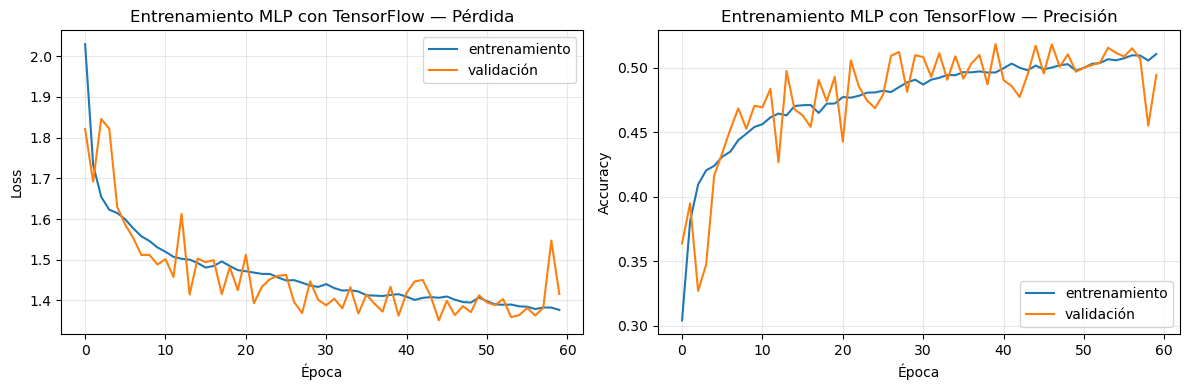

In [9]:
def graficar_historial(history, titulo):
    h = history.history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(h['loss'], label='entrenamiento')
    ax1.plot(h['val_loss'], label='validación')
    ax1.set_title(f'{titulo} — Pérdida')
    ax1.set_xlabel('Época'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(h['accuracy'], label='entrenamiento')
    ax2.plot(h['val_accuracy'], label='validación')
    ax2.set_title(f'{titulo} — Precisión')
    ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_historial(history_tf, 'Entrenamiento MLP con TensorFlow')
